In [1]:
# Cell 1: Setup and Load Data
import pandas as pd
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import average_precision_score, precision_recall_curve, auc
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

# 1. Set MLflow Experiment
# If the experiment doesn't exist, it will be created.
mlflow.set_experiment("Assignment_2_Exp_Tracking")

# 2. Load the current data (We are currently on Version 2 from prepare.ipynb)
print("Loading data...")
# Ensure these files exist from your prepare.ipynb execution
train_df = pd.read_csv('train.csv')
val_df = pd.read_csv('validation.csv')
test_df = pd.read_csv('test.csv')

# Check for missing values in text column (just in case) and fill them
train_df['message'] = train_df['message'].fillna('')
val_df['message'] = val_df['message'].fillna('')
test_df['message'] = test_df['message'].fillna('')

# Separate Features and Target
# Note: We select the 'message' column specifically as a Series for the vectorizer
X_train = train_df['message']
y_train = train_df['target']

X_val = val_df['message']
y_val = val_df['target']

X_test = test_df['message']
y_test = test_df['target']

print(f"Data Loaded Successfully.")
print(f"Training Info: {X_train.shape[0]} samples")
print(f"MLflow Experiment set to: 'Assignment_2_Exp_Tracking'")

c:\Users\abhim\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/02/15 22:58:32 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/15 22:58:32 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/15 22:58:32 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/15 22:58:32 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/15 22:58:32 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/15 22:58:32 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/02/15 22:58:32 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/02/15 22:58:32 INFO mlflow.store.db.utils: Updating database tables
202

Loading data...
Data Loaded Successfully.
Training Info: 3343 samples
MLflow Experiment set to: 'Assignment_2_Exp_Tracking'


In [2]:
# Cell 2: Train, Track, and Register 3 Benchmark Models
import mlflow
from mlflow.models.signature import infer_signature
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_recall_curve, auc
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

def train_and_log(model, model_name, X_train, y_train, X_val, y_val):
    """
    Trains a model (pipeline), logs params/metrics/model to MLflow, and registers it.
    """
    with mlflow.start_run(run_name=model_name):
        print(f"Training {model_name}...")
        
        # 1. Train
        # The model is now a Pipeline, so it first vectorizes the text, then trains
        model.fit(X_train, y_train)
        
        # 2. Predict Probabilities (for AUCPR)
        # The Pipeline handles the transformation of X_val internally
        y_probs = model.predict_proba(X_val)[:, 1]
        
        # 3. Calculate AUCPR
        precision, recall, _ = precision_recall_curve(y_val, y_probs)
        aucpr = auc(recall, precision)
        print(f"  > AUCPR: {aucpr:.4f}")
        
        # 4. Log Parameters and Metrics
        mlflow.log_param("model_type", model_name)
        mlflow.log_metric("aucpr", aucpr)
        
        # 5. Log and Register Model
        # infer_signature helps MLflow understand input/output schema (text input)
        prediction = model.predict(X_train)
        signature = infer_signature(X_train, prediction)
        
        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path="model",
            registered_model_name=model_name, # This registers the model!
            signature=signature
        )

# --- Run Experiments ---

# Model 1: Logistic Regression
# We create a Pipeline: Text -> Vectors -> Classifier
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(random_state=42))
])
train_and_log(lr_pipeline, "Logistic_Regression", X_train, y_train, X_val, y_val)

# Model 2: Random Forest
rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42))
])
train_and_log(rf_pipeline, "Random_Forest", X_train, y_train, X_val, y_val)

# Model 3: Decision Tree
dt_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', DecisionTreeClassifier(max_depth=5, random_state=42))
])
train_and_log(dt_pipeline, "Decision_Tree", X_train, y_train, X_val, y_val)

print("\nAll experiments completed and models registered.")

2026/02/15 22:58:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Training Logistic_Regression...
  > AUCPR: 0.9660


c:\Users\abhim\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)
Successfully registered model 'Logistic_Regression'.
Created version '1' of model 'Logistic_Regression'.
2026/02/15 22:58:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Training Random_Forest...
  > AUCPR: 0.9455


c:\Users\abhim\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)
Successfully registered model 'Random_Forest'.
Created version '1' of model 'Random_Forest'.
2026/02/15 22:58:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Training Decision_Tree...
  > AUCPR: 0.8186


c:\Users\abhim\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)



All experiments completed and models registered.


Successfully registered model 'Decision_Tree'.
Created version '1' of model 'Decision_Tree'.


In [3]:
# Cell 3: Retrieve and Print Model Metrics
import mlflow

# 1. Get the Experiment ID
experiment_name = "Assignment_2_Exp_Tracking"
current_experiment = mlflow.get_experiment_by_name(experiment_name)
experiment_id = current_experiment.experiment_id

# 2. Search Runs
# We grab the metrics and tags to display the name and the score
runs = mlflow.search_runs(experiment_ids=[experiment_id])

# 3. Filter and Display relevant columns
# 'tags.mlflow.runName' corresponds to the run_name we set (e.g., "Logistic_Regression")
# 'metrics.aucpr' is the metric we logged
results = runs[['tags.mlflow.runName', 'metrics.aucpr', 'run_id']].sort_values(by='metrics.aucpr', ascending=False)

print(f"=== Model Performance for Experiment: {experiment_name} ===\n")
print(results.to_string(index=False))

# Optional: Identify the best model
best_run = results.iloc[0]
print(f"\n🏆 Best Model: {best_run['tags.mlflow.runName']} with AUCPR: {best_run['metrics.aucpr']:.4f}")

=== Model Performance for Experiment: Assignment_2_Exp_Tracking ===

tags.mlflow.runName  metrics.aucpr                           run_id
Logistic_Regression       0.965958 d0a2f9811ee9409cb6fbb2002038ede5
      Random_Forest       0.945459 7f2d4442d23e4804bbc4eab7161cd7bb
      Decision_Tree       0.818560 05959b6b91864c68a1b0fcdac8b735f9

🏆 Best Model: Logistic_Regression with AUCPR: 0.9660


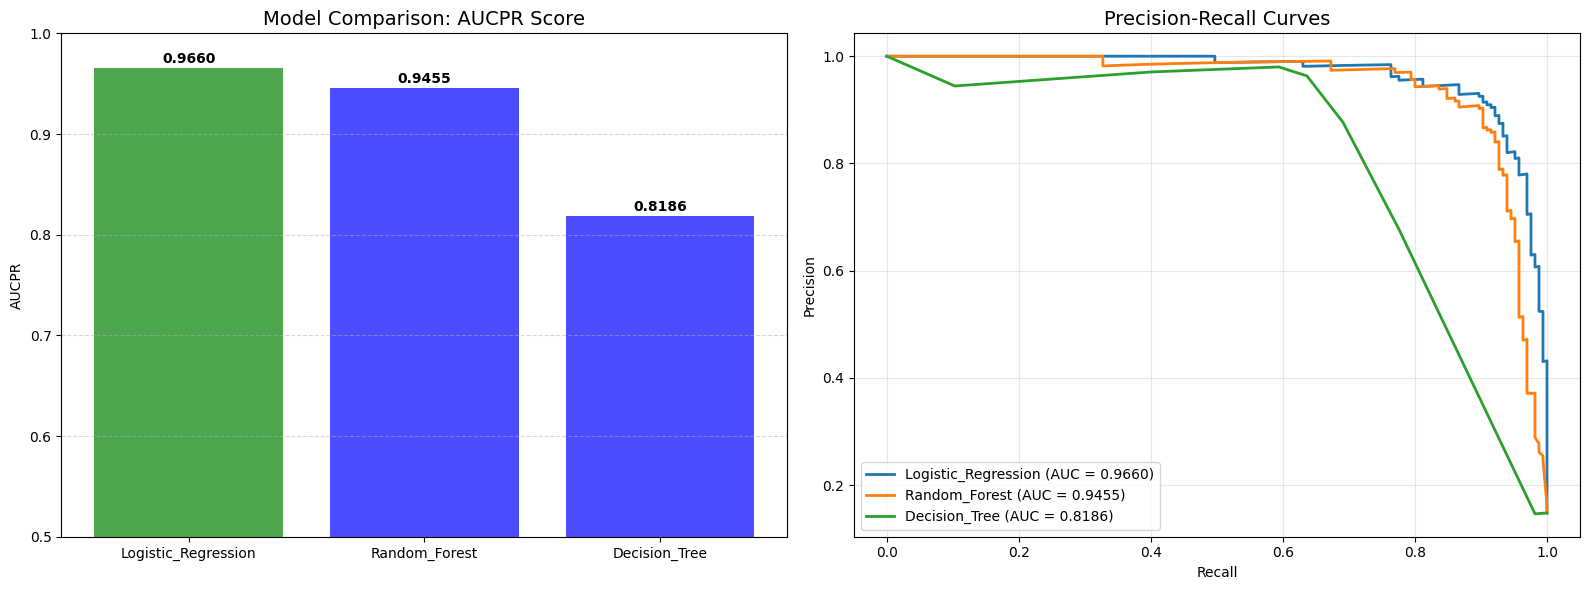

In [5]:
# Cell 4: Visualization of Model Performance
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# Set up the figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Bar Chart of AUCPR ---
# We use the 'results' dataframe from Cell 3. 
# We take .head(3) to ensure we compare the 3 models we just trained.
# (remove .head(3) if you want to see all historical runs)
latest_results = results.head(3).copy()

models = latest_results['tags.mlflow.runName']
scores = latest_results['metrics.aucpr']

# Highlight the best score in green, others in blue
colors = ['green' if x == max(scores) else 'blue' for x in scores]

ax1.bar(models, scores, color=colors, alpha=0.7)
ax1.set_ylim(0.5, 1.0) # Zoom in to see differences (adjusted range)
ax1.set_title('Model Comparison: AUCPR Score', fontsize=14)
ax1.set_ylabel('AUCPR')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Add text labels on bars
for i, v in enumerate(scores):
    # i is the index, v is the score value
    ax1.text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')

# --- Plot 2: Precision-Recall Curves ---
# UPDATE: We must use the PIPELINE objects (lr_pipeline, etc.) defined in Cell 2
# These pipelines handle the text vectorization automatically.
model_objects = {
    "Logistic_Regression": lr_pipeline,
    "Random_Forest": rf_pipeline,
    "Decision_Tree": dt_pipeline
}

for name, model in model_objects.items():
    # Get probabilities for the positive class (1)
    # The pipeline will convert X_val text to vectors internally
    y_probs = model.predict_proba(X_val)[:, 1]
    
    precision, recall, _ = precision_recall_curve(y_val, y_probs)
    auc_score = auc(recall, precision)
    
    # Plot curve
    ax2.plot(recall, precision, label=f'{name} (AUC = {auc_score:.4f})', linewidth=2)

ax2.set_title('Precision-Recall Curves', fontsize=14)
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc='lower left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

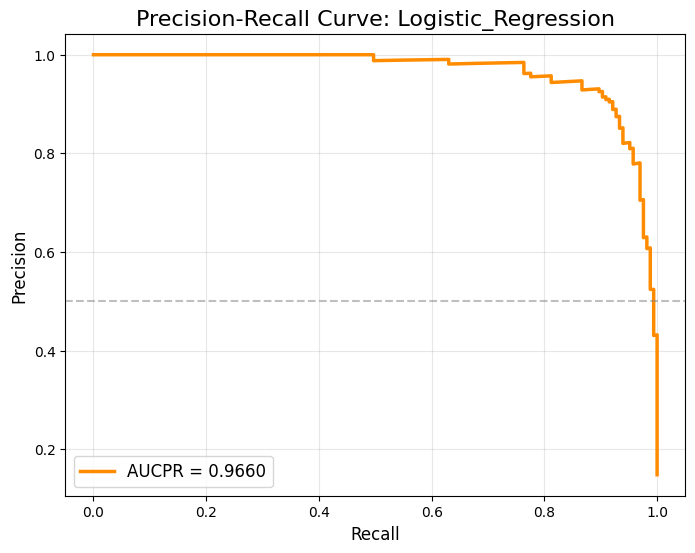

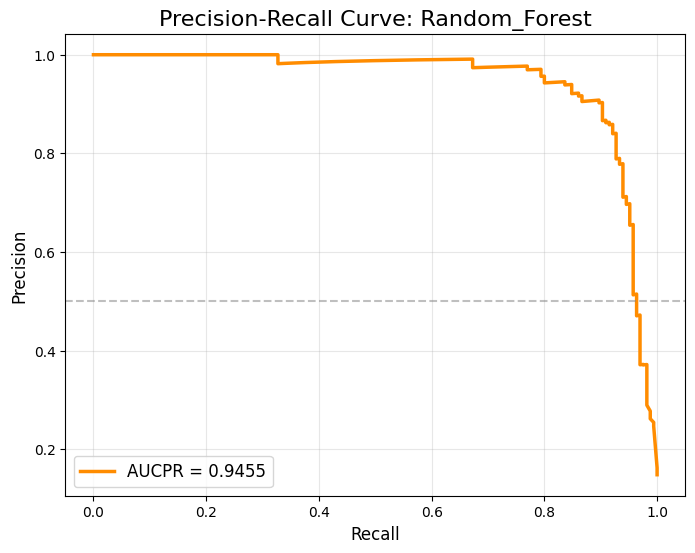

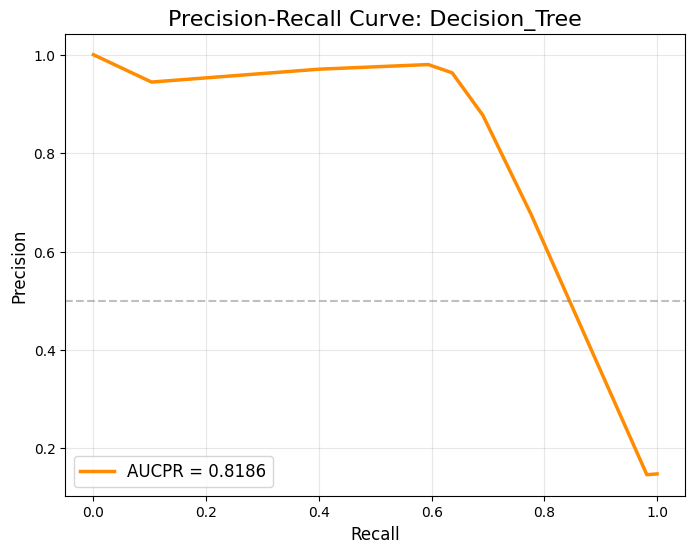

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# 1. Define the map of model names to their pipeline objects
# Ensure you have run Cell 2 so these objects exist
model_objects = {
    "Logistic_Regression": lr_pipeline,
    "Random_Forest": rf_pipeline,
    "Decision_Tree": dt_pipeline
}

# 2. Loop through each model and generate a separate plot
for name, model in model_objects.items():
    
    # Create a new figure for each model
    plt.figure(figsize=(8, 6))
    
    # Predict probabilities for the positive class (spam = 1)
    y_probs = model.predict_proba(X_val)[:, 1]
    
    # Calculate precision, recall, and AUCPR
    precision, recall, _ = precision_recall_curve(y_val, y_probs)
    auc_score = auc(recall, precision)
    
    # Plot the PR Curve
    plt.plot(recall, precision, label=f'AUCPR = {auc_score:.4f}', color='darkorange', linewidth=2.5)
    
    # Formatting the plot
    plt.title(f'Precision-Recall Curve: {name}', fontsize=16)
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5) # Reference line
    plt.legend(loc='lower left', fontsize=12)
    plt.grid(alpha=0.3)
    
    # Show the plot
    plt.show()